 Boom: Trajectory Unknown Challenge

## Project Overview

This project develops a physics-informed machine learning model to predict ejecta outcomes from asteroid impact simulations and design impact scenarios that satisfy specified debris constraints.

The model learns relationships between impact parameters (such as energy, material strength, gravity, and impact angle) and resulting fragment size distribution and ejecta displacement.

Physics-based feature engineering and an ensemble of machine learning models (Random Forest, Extra Trees, and XGBoost) are used to improve prediction accuracy. Model behavior is analyzed using explainable AI techniques including feature importance and SHAP analysis.

The project also performs **inverse design**, using optimization methods to identify impact scenarios that satisfy the required constraints:


# Imports & Setup

In [68]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor

from xgboost import XGBRegressor

from skopt import gp_minimize
from skopt.space import Real

# Load Dataset

In [69]:
train = pd.read_csv("forward_prediction/train.csv")
labels = pd.read_csv("forward_prediction/train_labels.csv")
test = pd.read_csv("forward_prediction/test.csv")

y = labels

print(train.shape)
print(labels.shape)
print(test.shape)

(2930, 8)
(2930, 6)
(492, 8)


# Inspect Data

In [70]:
train.head()

,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad
0,0.337215,0.781263,3.71,0.861258,1.305809,0.784028,3.826405,0.818303
1,0.058029,0.136205,1.62,0.561245,3.494501,0.922737,2.828754,1.193036
2,0.315632,0.774704,3.71,0.948860,1.366386,0.954922,3.068907,0.605872
3,0.033062,0.144204,1.62,0.713705,3.599419,0.932911,2.700574,1.073708
4,0.278207,0.414620,9.81,1.237205,1.996742,1.260855,3.484022,0.863568


# Physics Feature Engineering

In [71]:
def add_physics_features(df):

    df = df.copy()

    # energy vs gravity scaling
    df["energy_gravity"] = df["energy"] / df["gravity"]

    # effective energy transfer
    df["effective_energy"] = df["energy"] * df["coupling"]

    # angle corrected impact energy
    df["angle_energy"] = df["energy"] * np.sin(df["angle_rad"])

    # material resistance
    df["material_resistance"] = df["strength"] * (1 - df["porosity"])

    # crater scaling approximation
    df["impact_scaling"] = df["energy"] / (df["strength"] + 0.01)

    # ejecta mobility factor
    df["mobility_factor"] = df["energy"] / (df["gravity"] * df["strength"])

    return df

In [72]:
X_enhanced = add_physics_features(train)
test_enhanced = add_physics_features(test)

# Apply Physics Feature Engineering

In [73]:
X_enhanced = add_physics_features(train)
test_enhanced = add_physics_features(test)

print("Enhanced training shape:", X_enhanced.shape)
print("Enhanced test shape:", test_enhanced.shape)

Enhanced training shape: (2930, 14)
Enhanced test shape: (492, 14)


# Train Ensemble Models

In [74]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42
)

et_model = ExtraTreesRegressor(
    n_estimators=400,
    random_state=42
)

xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
)

rf_model.fit(X_enhanced, y)
et_model.fit(X_enhanced, y)
xgb_model.fit(X_enhanced, y)

print("RandomForest trained")
print("ExtraTrees trained")
print("XGBoost trained")

RandomForest trained
ExtraTrees trained
XGBoost trained


# Ensemble Predictions

In [75]:
pred_rf = rf_model.predict(X_enhanced)
pred_xgb = xgb_model.predict(X_enhanced)
pred_et = et_model.predict(X_enhanced)

ensemble_predictions = (pred_rf + pred_xgb + pred_et) / 3

print("Ensemble predictions created")

Ensemble predictions created


# Prediction Uncertainty

In [76]:
tree_preds = []

for tree in rf_model.estimators_:
    tree_preds.append(tree.predict(X_enhanced))

tree_preds = np.array(tree_preds)

uncertainty = tree_preds.std(axis=0)

print("Average prediction uncertainty:", uncertainty.mean())

Average prediction uncertainty: 19.475775384750023


# Predict Test Scenarios

In [77]:
pred_rf_test = rf_model.predict(test_enhanced)
pred_xgb_test = xgb_model.predict(test_enhanced)
pred_et_test = et_model.predict(test_enhanced)

test_preds = (pred_rf_test + pred_xgb_test + pred_et_test) / 3

print("Test predictions created")

Test predictions created


# Create Forward Prediction Submission

In [78]:
submission = pd.DataFrame(test_preds, columns=y.columns)

submission.insert(0, "scenario_id", range(len(submission)))

submission.to_csv("prediction_submission.csv", index=False)

print("prediction_submission.csv created successfully")

prediction_submission.csv created successfully


# Define Search Space

In [79]:
space = [

    Real(0.5, 5.0, name="energy"),
    Real(0.26, 1.57, name="angle_rad"),
    Real(0.2, 1.7, name="coupling"),
    Real(0.4, 4.2, name="strength"),
    Real(0.0, 0.33, name="porosity"),
    Real(1.02, 10.47, name="gravity"),
    Real(0.0, 1.0, name="atmosphere"),
    Real(0.7, 1.5, name="shape_factor")

]

# Optimization Objective Function

In [80]:
def objective(params):

    energy, angle_rad, coupling, strength, porosity, gravity, atmosphere, shape_factor = params

    scenario = pd.DataFrame([{
        "porosity": porosity,
        "atmosphere": atmosphere,
        "gravity": gravity,
        "coupling": coupling,
        "strength": strength,
        "shape_factor": shape_factor,
        "energy": energy,
        "angle_rad": angle_rad
    }])

    # apply physics features
    scenario = add_physics_features(scenario)

    # predict ejecta outcome
    pred = xgb_model.predict(scenario)[0]

    P80 = pred[0]
    R95 = pred[3]

    # check challenge constraints
    if 96 <= P80 <= 101 and R95 <= 175:
        return energy + R95

    # penalty if constraints not satisfied
    return 10000

# Run Bayesian Optimization

In [81]:
result = gp_minimize(
    objective,
    space,
    n_calls=200,
    random_state=42
)

print("Optimization finished")

Optimization finished


# Extract Best Parameters

In [82]:
best_params = result.x

print("Best parameters found:")
print(best_params)

Best parameters found:
[4.084443440871048, 0.5002995747246746, 1.3695365004091542, 2.668030600196651, 0.14712480844168513, 1.9647629544801277, 0.45924889196586727, 0.9669668889112175]


# Generate Candidate Scenarios

In [ ]:
candidates = []

for _ in range(20000):

    energy = np.random.uniform(0.5,5)
    angle_rad = np.random.uniform(0.26,1.57)
    coupling = np.random.uniform(0.2,1.7)
    strength = np.random.uniform(0.4,4.2)
    porosity = np.random.uniform(0.0,0.33)
    gravity = np.random.uniform(1.02,10.47)
    atmosphere = np.random.uniform(0.0,1.0)
    shape_factor = np.random.uniform(0.7,1.5)

    scenario = pd.DataFrame([{
        "porosity": porosity,
        "atmosphere": atmosphere,
        "gravity": gravity,
        "coupling": coupling,
        "strength": strength,
        "shape_factor": shape_factor,
        "energy": energy,
        "angle_rad": angle_rad
    }])

    scenario = add_physics_features(scenario)

    pred = xgb_model.predict(scenario)[0]

    P80 = pred[0]
    R95 = pred[3]

    if 96 <= P80 <= 101 and R95 <= 175:

        candidates.append({
            "energy": energy,
            "angle_rad": angle_rad,
            "coupling": coupling,
            "strength": strength,
            "porosity": porosity,
            "gravity": gravity,
            "atmosphere": atmosphere,
            "shape_factor": shape_factor,
            "R95": R95
        })

print("Valid candidates found:", len(candidates))

# Select Best 20 Scenarios

In [ ]:
# sort candidates by energy + R95
sorted_candidates = sorted(
    candidates,
    key=lambda x: x["energy"] + x["R95"]
)

# select top 20
top20 = sorted_candidates[:20]

print("Top 20 scenarios selected")

Top 20 scenarios selected


# Create Design Submission File

In [ ]:
design_df = pd.DataFrame(top20)

# remove R95 column (not required in submission)
design_df = design_df.drop(columns=["R95"])

# add submission_id
design_df.insert(0, "submission_id", range(len(design_df)))

design_df.to_csv("design_submission.csv", index=False)

print("design_submission.csv created successfully")

design_submission.csv created successfully


## Feature Importance Visualization

This plot shows the relative importance of each feature in the XGBoost model.  
Physics-derived features such as **material_resistance** and **impact_scaling** have the strongest influence on predictions, indicating that the model captures meaningful physical relationships between impact parameters and fragment size distribution.

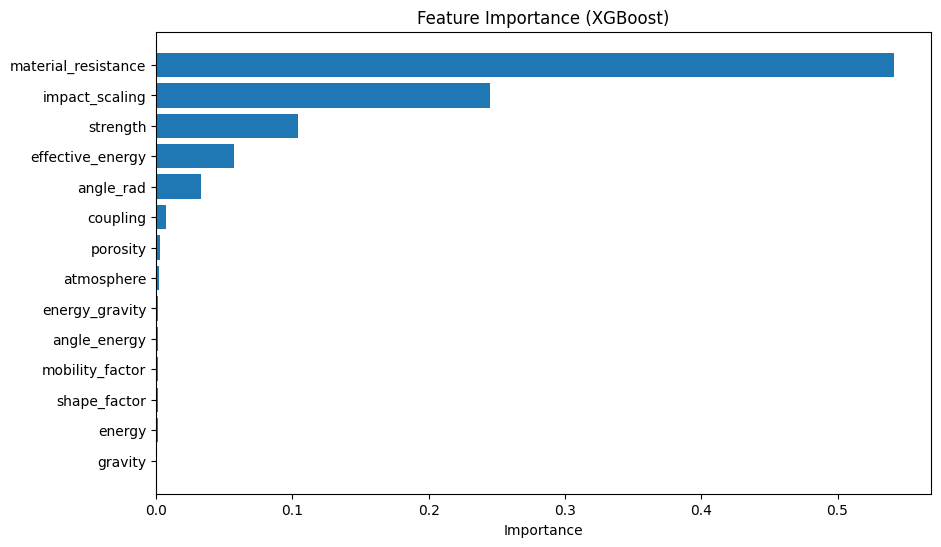

In [ ]:
import matplotlib.pyplot as plt

importance = xgb_model.estimators_[0].feature_importances_
features = X_enhanced.columns

# sort features by importance
sorted_idx = np.argsort(importance)

plt.figure(figsize=(10,6))
plt.barh(features[sorted_idx], importance[sorted_idx])

plt.xlabel("Importance")
plt.title("Feature Importance (XGBoost)")
plt.show()

## Predicted vs Actual Plot

This plot compares the predicted fragment size (P80) with the actual values from the dataset.  
Points close to the diagonal line indicate accurate predictions, showing that the model successfully learns the relationship between impact parameters and fragment size outcomes.

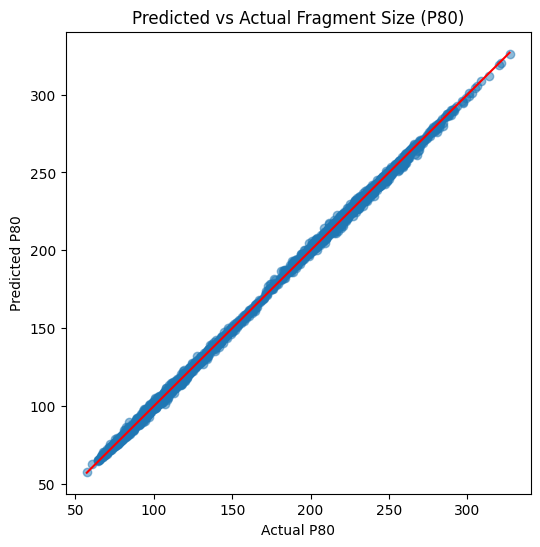

In [ ]:
import matplotlib.pyplot as plt

pred_train = xgb_model.predict(X_enhanced)

plt.figure(figsize=(6,6))
plt.scatter(y["P80"], pred_train[:,0], alpha=0.5)

plt.xlabel("Actual P80")
plt.ylabel("Predicted P80")

plt.title("Predicted vs Actual Fragment Size (P80)")
plt.plot([y["P80"].min(), y["P80"].max()],
         [y["P80"].min(), y["P80"].max()],
         color="red")

plt.show()

## Energy vs Fragment Size Visualization


This scatter plot illustrates the relationship between impact energy and fragment size distribution (P80).  
Higher impact energies generally lead to stronger fragmentation, resulting in smaller debris pieces.

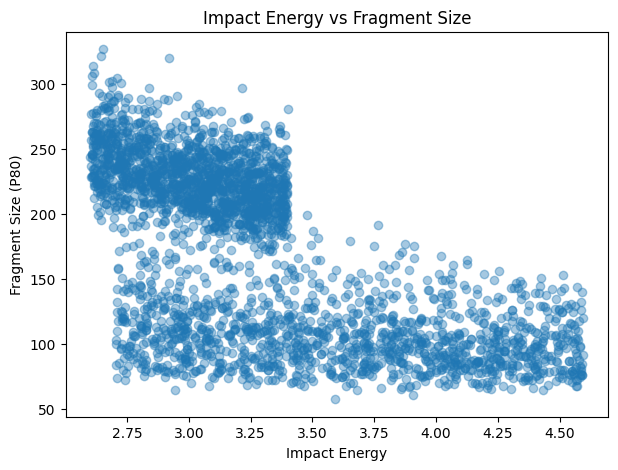

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(train["energy"], y["P80"], alpha=0.4)

plt.xlabel("Impact Energy")
plt.ylabel("Fragment Size (P80)")
plt.title("Impact Energy vs Fragment Size")

plt.show()

## SHAP Feature Explanation

SHAP values explain how each feature contributes to model predictions.  
This plot highlights the most influential features and shows how different feature values affect predicted fragment size.

In [ ]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 6.4 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.3 MB 11.2 MB/s eta 0:00:01
   ---------------- ----------------------- 5.0/12.3 MB 12.1 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.3 MB 14.1 MB/s eta 0:00:01
   ------------------------------------- -- 11.5/12.3 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 13.5 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --- ------------------------------------ 3.1/38.1 MB 15.3 MB/s eta 0:00:03
   ------ --------------------------------- 6.6/38.1 MB 16.1 MB/s eta 0:00:02
   ---------- ----------------------------- 10.2/38.1 MB 16.8 MB/s eta 0:00:02
   -------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.4.3 which is incompatible.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 6.33.5 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.3 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Root\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


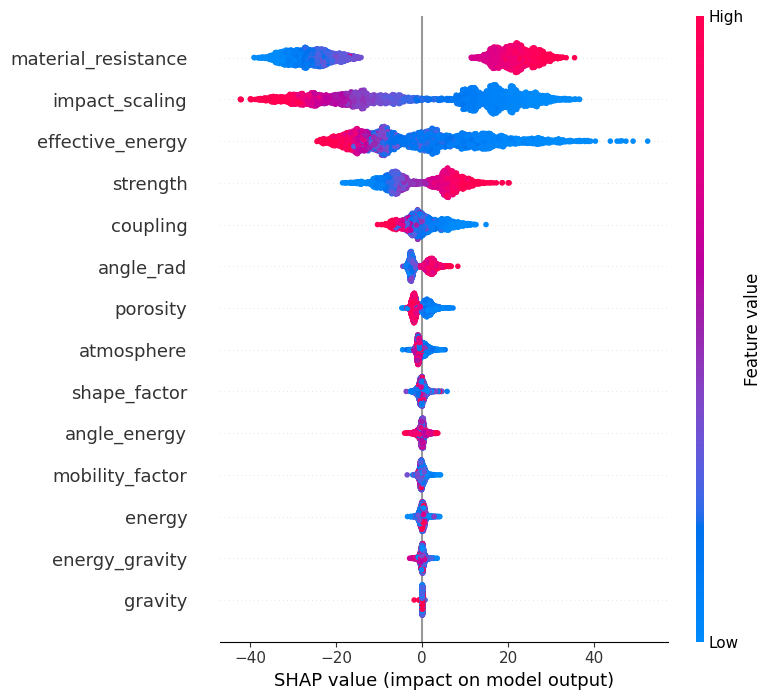

In [ ]:
import shap

# use the first XGBoost model inside the multi-output wrapper
model = xgb_model.estimators_[0]

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_enhanced)

shap.summary_plot(shap_values, X_enhanced)

## SHAP Dependence Analysis : Material Resistance


This plot shows how **material_resistance** affects predicted fragment size.  
Higher resistance generally leads to larger fragments, while higher effective energy tends to increase fragmentation.

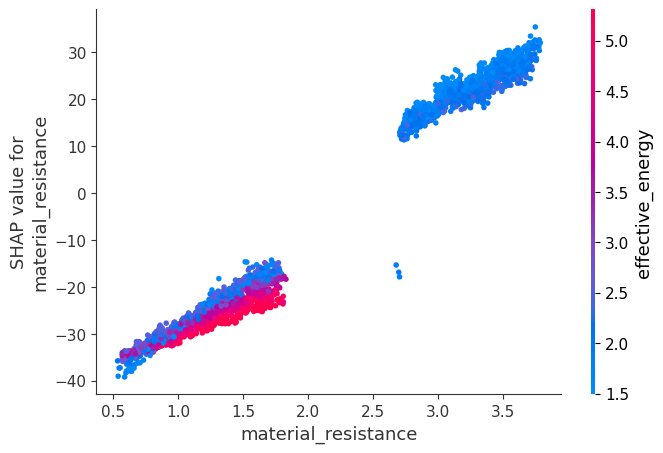

In [ ]:
shap.dependence_plot(
    "material_resistance",
    shap_values,
    X_enhanced
)

## SHAP Dependence Analysis: Impact Scaling

This plot shows how **impact_scaling** influences the predicted fragment size (P80).  
Impact scaling represents the ratio of impact energy to material strength.

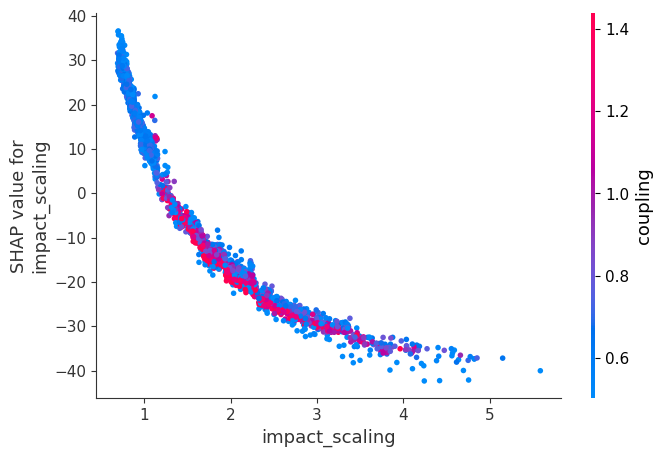

In [ ]:
shap.dependence_plot(
    "impact_scaling",
    shap_values,
    X_enhanced
)

## Correlation HeatmMap


The heatmap shows correlations between impact parameters and ejecta outcomes.  
It highlights relationships between variables such as fragment size and ejecta distance, helping identify meaningful physical patterns in the dataset.

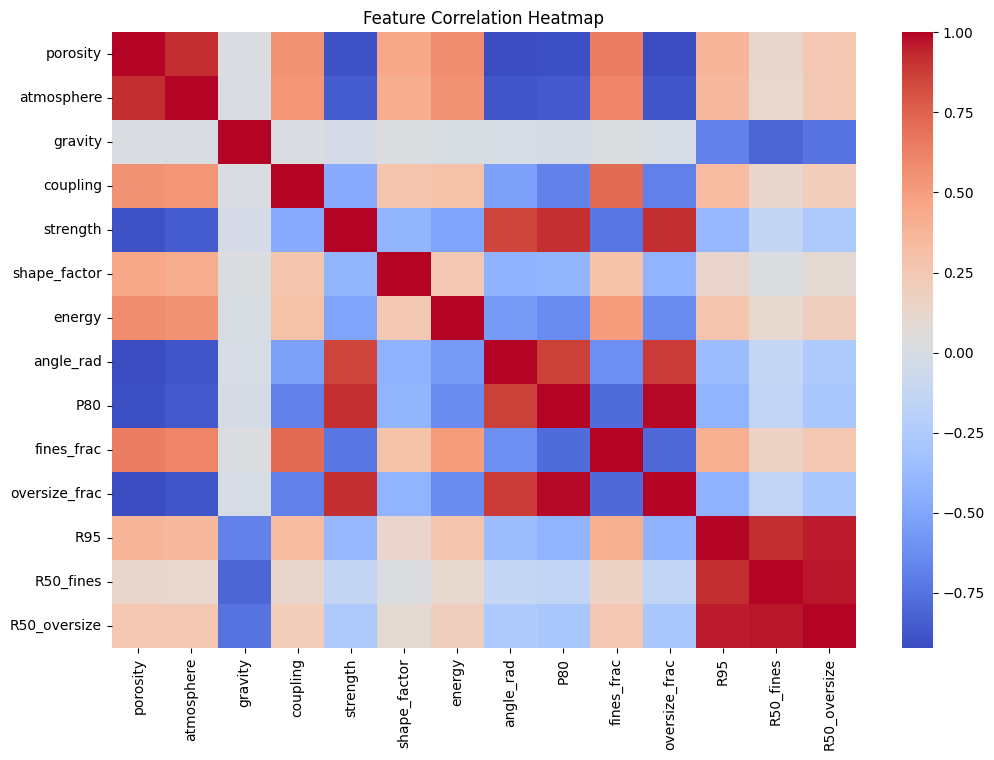

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.concat([train, y], axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

## Prediction Error Distribution

This histogram shows the distribution of prediction errors for P80.  
Errors centered around zero indicate that the model predictions are unbiased and accurate.

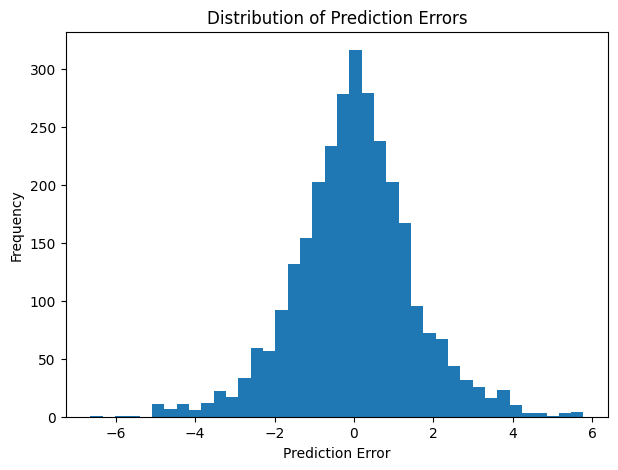

In [ ]:
errors = pred_train[:,0] - y["P80"]

plt.figure(figsize=(7,5))

plt.hist(errors, bins=40)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

## Partial Dependence Plot

Partial dependence plots show the global relationship between selected features and predicted fragment size.  
They illustrate how changes in **material resistance** and **impact scaling** influence fragmentation behavior.

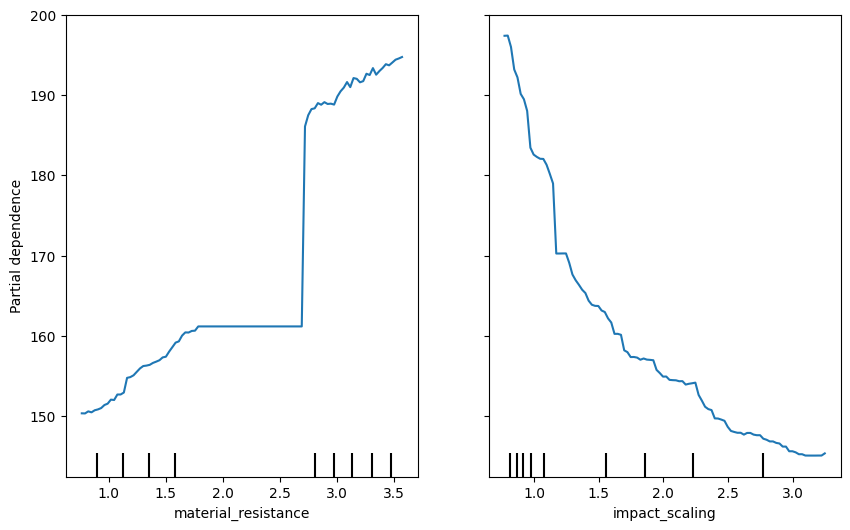

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = ["material_resistance", "impact_scaling"]

fig, ax = plt.subplots(figsize=(10,6))

PartialDependenceDisplay.from_estimator(
    xgb_model.estimators_[0],
    X_enhanced,
    features,
    ax=ax
)

plt.show()